### **Imports Iniciales**

In [1]:
import re, time, unicodedata, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display

# NLP clásico
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize, sent_tokenize

# Representación y modelos (solo scikit-learn, sin redes neuronales)
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier

# Evaluación
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

warnings.filterwarnings(action='ignore')
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
plt.style.use(style='seaborn-v0_8-whitegrid')

SEMILLA = 42
CLASES = ['negativo', 'neutral', 'positivo']
print('✓ Entorno listo')

✓ Entorno listo


### **1. Carga de datos**

In [2]:
train_raw = pd.read_csv('data/train.csv')
eval_raw = pd.read_csv('data/eval.csv')

display(train_raw.head())

,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


### **2. Calidad de datos**

Para la verificación de la calidad de datos, se parte por la siguiente hipótesis: Que la columna *id* sea única no garantiza que los datos no lo sean, por lo que se va a verificar la **dimensiones de calidad** de las filas en dos niveles:

1. **Estructural:** *id* único, nulos, textos vacíos, etiquetas válidas. Esto quiere decir que en este nivel, se verificará la **unicidad**, **completitud** y **consistencia** en su forma "clásica".
2. **De contenido:** Textos repetidos (exactos y casi exactos) y, sobre todo, textos con **etiquetas distintas** (ruido de etiqueta). Es decir, se verificará la **unicidad** y **consistencia** de los datos.

Se hace esta verificación porque si una reseña duplicada cae en el fold de entrenamiento y en el de validación a la vez, la exactitud de validación se infla (data leakage) y elegiríamos hiperparámetros con una métrica optimista (sobreestima los datos).

In [3]:
def auditar(df, nombre, con_label=True):
    print(f'-- {nombre} --')
    print(f'Filas: {len(df):,}')
    print(f'Nulos por columna: {df.isna().sum().to_dict()}')
    print(f'IDs únicos: {df["id"].is_unique} (IDs repetidos: {df["id"].duplicated().sum()})')
    print(f'Textos vacíos o solo espacios: {df["text"].fillna("").str.strip().eq("").sum()}')
    if con_label:
        etiquetas = df["label"].astype(str).str.strip().str.lower()
        fuera = sorted(set(etiquetas) - set(CLASES))
        print(f'Etiquetas fuera de {CLASES}: {fuera if fuera else "ninguna"}')
        print(f'Etiquetas con espacios/Mayúsculas por corregir: {(etiquetas != df["label"]).sum()}')
    print()

auditar(train_raw, 'train')
auditar(eval_raw, 'eval', con_label = False)

-- train --
Filas: 12,000
Nulos por columna: {'id': 0, 'text': 0, 'label': 0}
IDs únicos: True (IDs repetidos: 0)
Textos vacíos o solo espacios: 0
Etiquetas fuera de ['negativo', 'neutral', 'positivo']: ninguna
Etiquetas con espacios/Mayúsculas por corregir: 0

-- eval --
Filas: 3,000
Nulos por columna: {'id': 0, 'text': 0}
IDs únicos: True (IDs repetidos: 0)
Textos vacíos o solo espacios: 0



In [4]:
#Se crea una columna auxiliar 'clave' "laxa" para comparar el parecido con 'text'

def clave_duplicado(s):
    #Estandariza espacios
    return s.fillna('').str.lower().str.replace(r'\s+', ' ', regex=True)

#Se hace una copia del dataset de entrenamiento como buena práctica
train = train_raw.copy()
train['label'] = train['label'].astype(str).str.strip().str.lower()
train['clave'] = clave_duplicado(train['text'])

grupos = train.groupby('clave')['label'].agg(['size', 'nunique'])
dup_mismo_label = grupos[(grupos['size'] > 1) & (grupos['nunique'] == 1)]
dup_conflicto = grupos[grupos['nunique'] > 1]

print(f'Duplicados exactos (texto crudo): {train["text"].duplicated().sum()}')
print(f'Duplicados por clave laxa: {train["clave"].duplicated().sum()}')
print(f'grupos con la misma etiqueta: {len(dup_mismo_label)} (filas sobrantes: {(dup_mismo_label["size"] - 1).sum()})')
print(f'Grupos con etiquetas en conflicto: {len(dup_conflicto)} (filas involucradas: {dup_conflicto["size"].sum()})')

if len(dup_conflicto):
    display(train[train['clave'].isin(dup_conflicto.index)].sort_values('clave')[['id', 'text', 'label']].head(10))

#Unicamente se verifica si hay datos solapados entre datos de train y eval
solapamiento = set(train['clave']) & set(clave_duplicado(eval_raw['text']))
print(f'Textos de eval que también aparecen en train: {len(solapamiento)}')

Duplicados exactos (texto crudo): 0
Duplicados por clave laxa: 0
grupos con la misma etiqueta: 0 (filas sobrantes: 0)
Grupos con etiquetas en conflicto: 0 (filas involucradas: 0)
Textos de eval que también aparecen en train: 0


In [5]:
n_inicial = len(train)
train = train[train['clave'] != '']
train = train[~train['clave'].isin(dup_conflicto.index)]
train = train.drop_duplicates(subset='clave', keep = 'first')
train = train.drop(columns='clave').reset_index(drop=True)

eval_df = eval_raw.copy()
eval_df['text'] = eval_df['text'].fillna('')

print(f'train: {n_inicial:,}: {len(train):,} filas (eliminadas: {n_inicial - len(train):,})')

train: 12,000: 12,000 filas (eliminadas: 0)


**Resultado:** el conjunto de datos no presenta problemas en ninguna de las dimensiones evaluadas:

- **Completitud:** no hay nulos ni textos vacíos en `train` ni en `eval`.
- **Unicidad:** no hay IDs repetidos ni reseñas duplicadas (ni exactas ni con la clave laxa).
- **Consistencia:** todas las etiquetas pertenecen a las tres clases válidas y no existen textos iguales con etiquetas distintas.
- **Fuga de información:** ninguna reseña de `eval` aparece en `train`.

La limpieza de la celda anterior no elimina filas, pero se conserva para que el flujo sea robusto si los datos cambian.

### **3. Exploración rápida**

- Balanceo de clases
- Longitud de las reseñas
- Diferencia de palabras de negación y contraste por clase (para no tratarlas como *stopwords*)
- Estructura de las reseñas: oraciones y conectores contrastivos

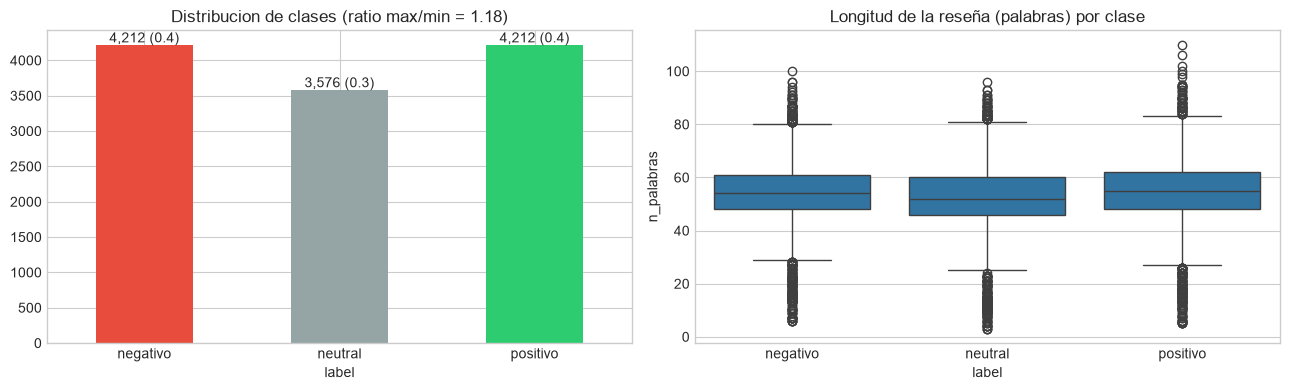

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negativo,4212.0,54.2,12.7,6.0,48.0,54.0,61.0,100.0
neutral,3576.0,52.3,13.9,3.0,46.0,52.0,60.0,96.0
positivo,4212.0,55.0,13.0,5.0,48.0,55.0,62.0,110.0


In [6]:
conteo = train['label'].value_counts().reindex(CLASES)
ratio_desbalance = conteo.max() / conteo.min()
train['n_palabras'] = train['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
conteo.plot.bar(ax = axes[0], color = ['#E74C3C', '#95A5A6', '#2ECC71'], rot = 0)
axes[0].set_title(f'Distribucion de clases (ratio max/min = {ratio_desbalance:.2f})')
for i, v in enumerate(conteo):
    axes[0].text(i, v, f'{v:,} ({v / conteo.sum():.1f})', ha='center', va='bottom')
sns.boxplot(data=train, x='label', y='n_palabras', order=CLASES, ax=axes[1])
axes[1].set_title('Longitud de la reseña (palabras) por clase')
plt.tight_layout()
plt.show()

display(train.groupby('label')['n_palabras'].describe().reindex(CLASES).round(1))

In [7]:
# % de reseñas de cada clase que contienen el marcador
marcadores = ['no', 'nunca', 'nada', 'sin', 'pero', 'aunque', 'sin embargo', 'muy']
tabla = pd.DataFrame({
    m: train.groupby('label')['text'].apply(lambda s: s.str.lower().str.contains(rf'\b{m}\b', regex = True).mean() * 100) for m in marcadores
}).reindex(CLASES)
display(tabla.round(1))

PATRON_ESPECIALES = r'[^a-zA-ZáéíóúüñÁÉÍÓÚÜÑ0-9\s.,;:!?¡¿()\'"\-]'
otros = train['text'].str.findall(PATRON_ESPECIALES).explode().dropna()
pct_especiales = train['text'].str.contains(PATRON_ESPECIALES, regex=True).mean()
print(f'Reseñas con caracteres especiales: {pct_especiales:.1%}')
print('Más frecuentes: ', otros.value_counts().head(15).to_dict())

,no,nunca,nada,sin,pero,aunque,sin embargo,muy
label,,,,,,,,
negativo,27.1,0.2,18.3,23.4,9.5,4.9,1.5,10.8
neutral,40.6,0.1,27.3,27.7,3.7,2.7,0.0,0.2
positivo,25.9,0.2,16.5,23.4,3.8,3.9,1.4,8.2


Reseñas con caracteres especiales: 0.1%
Más frecuentes:  {'Ã': 24, '\xad': 16, '³': 4, '±': 3, '©': 3, 'ì': 3, 'è': 2, 'à': 2, 'º': 1, '%': 1, 'ò': 1}


Solo el 0.1% de las reseñas (4 en train, ninguna en eval) tiene caracteres extraños como "Ã" o "\xad" . No son emojis ni ruido intencional: es **mojibake**, texto UTF-8 que fue leído como Latin-1 (por ejemplo aquÃ\xad → aquí, reseÃ±a → reseña). En lugar de eliminarlos, se reparan en el preprocesamiento con la función reparar_codificacion (sección 4).

In [8]:
train['n_oraciones'] = train['text'].apply(lambda s: len(sent_tokenize(s, language = 'spanish')))
display(train.groupby('label')['n_oraciones'].describe().reindex(CLASES).round(2))
print(f'Reseñas con más de una oración: {(train["n_oraciones"] > 1).mean():.1%}')

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negativo,4212.0,3.85,0.79,1.0,3.0,4.0,4.0,7.0
neutral,3576.0,3.89,0.73,1.0,4.0,4.0,4.0,6.0
positivo,4212.0,3.93,0.78,1.0,4.0,4.0,4.0,7.0


Reseñas con más de una oración: 98.9%


In [9]:
# Conectores contrastivos más frecuentes en el corpus (se unen en un solo token en la sección 4)
CONTRASTE_RE = re.compile(
    r'\b(pero|aunque|sin embargo|no obstante|aun as[ií]|eso s[ií]|por otro lado|con todo|al final|de todos modos|de todas formas)\b',
    flags=re.IGNORECASE)

conectores = train['text'].str.findall(CONTRASTE_RE).explode().dropna().str.lower().map(lambda c: unicodedata.normalize('NFKD', c).encode('ascii', 'ignore').decode())
display(conectores.value_counts().to_frame('apariciones').T)

train['n_conectores'] = train['text'].str.count(CONTRASTE_RE)
tabla_conectores = pd.crosstab(train['label'], train['n_conectores'].clip(upper=2), normalize='index').mul(100).round(1)
tabla_conectores.columns = ['0 conectores', '1 conector', '2 o más']
display(tabla_conectores.reindex(CLASES))

text,eso si,al final,aun asi,por otro lado,pero,aunque,con todo,sin embargo,de todos modos,de todas formas
apariciones,1734,1234,752,737,695,468,435,122,17,11


,0 conectores,1 conector,2 o más
label,,,
negativo,41.8,46.2,12.0
neutral,87.4,11.9,0.7
positivo,47.2,42.6,10.2


In [10]:
# Una reseña completa por clase para ver su estructura
with pd.option_context('display.max_colwidth', None):
    display(train.groupby('label').sample(1, random_state=7)[['label', 'text']].reindex(columns=['label', 'text']))

,label,text
7190,negativo,"Lo compré hace un par de meses para usar en casa, nada del otro mundo en cuanto a envío, llegó en unos cuatro días. El soporte técnico vale totalmente la pena, la verdad me atendieron cuando llamé por una duda de instalación. Por otro lado, le pondría una estrella al menú de ajustes. Total, que tengo sentimientos encontrados con esto."
3991,neutral,"Lo compré hace unos días en línea y me llegó al tercer día. Viene en color gris, tal como se ve en las fotos. Lo llevo a todas partes, lo tengo en la mochila para el trabajo. Pesa poco y no ocupa espacio."
2660,positivo,"Bueno, me animo a comentar porque lo compré hace un mes y medio en una oferta de esas de medianoche. El rendimiento es justo lo que estaba buscando, la verdad. Ahora, el procesador me dio más de un dolor de cabeza, sobre todo la primera semana que lo estuve configurando en la oficina. Todavía no me decido."


**Conclusiones de la exploración**

1. **Clases casi balanceadas** (ratio max/min ≈ 1.18). No se necesita remuestreo y la exactitud (*accuracy*), que es la métrica de la competencia, es representativa. Se descarta SMOTE: además de innecesario, interpolar vectores TF-IDF dispersos genera "documentos" artificiales sin sentido lingüístico.
2. **La longitud no discrimina:** las tres clases tienen distribuciones casi idénticas de palabras (~54) y oraciones (~4).
3. **La negación no es sinónimo de negatividad:** *no*, *nada* y *sin* son **más** frecuentes en las reseñas neutrales que en las negativas (p. ej. "sin nada fuera de lo común"). Por eso no se eliminan como *stopwords*, pero tampoco se tratan como señal negativa directa: se marca su alcance.
4. **Intensificadores y conectores sí son informativos:** *muy* casi no aparece en neutrales (0.2%) y *pero* es 2.5 veces más frecuente en negativas.
5. **Estructura de las reseñas:** las primeras oraciones suelen ser logística (cuándo se compró, cuánto tardó el envío, dónde se usa) y no aportan sentimiento. El 87% de las reseñas neutrales no tiene ningún conector contrastivo, frente a solo el 42-47% de las positivas y negativas. Más de la mitad de las reseñas con sentimiento tiene al menos un conector, señal de que mezcla un elogio y una queja, y en muchas de ellas el sentimiento global coincide con **la última opinión expresada** (recencia), tal como advierte el enunciado. No es una regla absoluta: la reseña positiva de ejemplo termina con una queja. Esta observación motiva la segmentación posicional de la sección 5.

### **4. Preprocesamiento adaptado a análisis de sentimiento**

In [11]:
def sin_tildes(s):

    s = s.replace('ñ', '§')
    s = ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))
    return s.replace('§', 'ñ')

def reparar_codificacion(s):
    # Corrige texto UTF-8 leído como Latin-1 (mojibake), p. ej. 'aquÃ\xad' -> 'aquí'
    if re.search(r'[ÃÂ]', s):
        try:
            s = s.encode('latin1').decode('utf8')
        except UnicodeError:
            pass
    return s.replace('\xad', '')

# Conectores de varias palabras que se unen en un solo token (las claves son regex: 'aun así' / 'aun asi')
CONECTORES_MULTI = {'sin embargo': 'sin_embargo', 'no obstante': 'no_obstante', 'a pesar de': 'a_pesar_de',
                    'aun as[ií]': 'aun_asi', 'eso s[ií]': 'eso_si', 'por otro lado': 'por_otro_lado',
                    'con todo': 'con_todo', 'al final': 'al_final',
                    'de todos modos': 'de_todos_modos', 'de todas formas': 'de_todas_formas'}
NEGADORES  = {'no', 'ni', 'nunca', 'jamas', 'tampoco', 'sin', 'nada', 'nadie', 'ningun', 'ninguno', 'ninguna'}
# 'igual' no se incluye: en el corpus suele ser comparativo ("el color es igual al de las fotos")
ADVERSATIVOS = {'pero', 'sino', 'sin_embargo', 'no_obstante', 'aun_asi', 'eso_si', 'por_otro_lado',
                'con_todo', 'al_final', 'de_todos_modos', 'de_todas_formas'}
CONCESIVOS   = {'aunque', 'a_pesar_de'}
INTENSIDAD = {'muy', 'mas', 'menos', 'mucho', 'mucha', 'muchos', 'muchas', 'poco', 'poca', 'pocos', 'pocas',
              'tan', 'tanto', 'demasiado', 'bastante', 'algo', 'todo'}

PALABRAS_A_CONSERVAR = NEGADORES | ADVERSATIVOS | CONCESIVOS | INTENSIDAD
stop_nltk = {sin_tildes(w) for w in stopwords.words('spanish')}
STOPWORDS_SENTIMIENTO = stop_nltk - PALABRAS_A_CONSERVAR

print(f'Stopwords NLTK: {len(stop_nltk)}: personalizadas: {len(STOPWORDS_SENTIMIENTO)}')
print('Rescatadas de la lista de NLTK:', sorted(stop_nltk & PALABRAS_A_CONSERVAR))

Stopwords NLTK: 306: personalizadas: 293
Rescatadas de la lista de NLTK: ['algo', 'mas', 'mucho', 'muchos', 'muy', 'nada', 'ni', 'no', 'pero', 'poco', 'sin', 'tanto', 'todo']


In [12]:
PALABRA_RE = re.compile(r'[a-záéíóúüñ_]+|\d+(?:[.,]\d+)?')
PUNTUACION = set('.,;:!?¡¿()') | {'...'}
stemmer = SnowballStemmer('spanish')
SUPERLATIVO_RE = re.compile(r'\b([a-záéíóúñ]{3,}?)[ií]sim[oa]s?\b')

def _superlativo(m):
    raiz = m.group(1)
    if raiz.endswith('qu'):
        raiz = raiz[:-2] + 'c'
    elif raiz.endswith('gu'):
        raiz = raiz[:-1]
    elif raiz.endswith('bil'):
        return f'muy {raiz[:-3]}ble'
    return f'muy {raiz}o'

def preprocesar(texto, stemming=True, quitar_tildes=True, negacion=True, ventana_neg=3, contraste=False, numeros='mantener'):

    if not isinstance(texto, str):
        return ''

    t = reparar_codificacion(texto).lower()
    t = re.sub(r'https?://\S+|www\.\S+', ' ', t)
    t = re.sub(r'([aeiouáéíóú])\1{2,}', r'\1', t)
    t = re.sub(r'(.)\1{2,}', r'\1\1', t)
    t = SUPERLATIVO_RE.sub(_superlativo, t)
    for frase, unido in CONECTORES_MULTI.items():
        t = re.sub(r'\b' + frase.replace(' ', r'\s+') + r'\b', unido, t)
    if numeros == 'eliminar':
        t = re.sub(r'\d+(?:[.,]\d+)?', ' ', t)
    elif numeros == 'token':
        t = re.sub(r'\d+(?:[.,]\d+)?', ' num ', t)
    t = re.sub(r'([¡¿])', r' \1 ', t)

    salida, neg_restante, idx_contraste = [], 0, -1
    for tok in word_tokenize(t, language='spanish'):
        if tok in PUNTUACION:
            neg_restante = 0
            continue
        tok = tok.rstrip('.')
        if not PALABRA_RE.fullmatch(tok):
            continue
        base = sin_tildes(tok)
        if base in STOPWORDS_SENTIMIENTO:
            continue
        if base in PALABRAS_A_CONSERVAR:
            forma = base
        elif  base[0].isdigit():
            forma = re.sub(r'[.,]', '_', base)
        else:
            forma = stemmer.stem(tok) if stemming else tok
            if quitar_tildes:
                forma = sin_tildes(forma)
            if negacion and neg_restante > 0:
                forma = 'neg' + forma
                neg_restante -= 1

        if base in ADVERSATIVOS or base in CONCESIVOS:
            neg_restante = 0
        if negacion and base in NEGADORES:
            neg_restante = ventana_neg

        salida.append(forma)
        if base in ADVERSATIVOS:
            idx_contraste = len(salida)  # posición de la primera palabra después del conector


    if contraste and idx_contraste >= 0:
        salida = salida[:idx_contraste] + ['tras_' + w for w in salida[idx_contraste:]]
    return ' '.join(salida)

Se verifica el comportamiento de preprocesar en un ejemplo con negación y contraste, y la reparación de codificación en una reseña real con mojibake:

In [13]:
ejemplo = 'La batería es excelente, pero la cámara no funciona bien. Aun así, la volvería a comprar.'
print(ejemplo)
for nombre, kwargs in {'base': dict(negacion=False), 'negación': dict(negacion=True),
                       'negación + contraste': dict(negacion=True, contraste=True)}.items():
    print(f'  {nombre:22s}→ {preprocesar(ejemplo, **kwargs)}')

con_mojibake = train.loc[train['text'].str.contains('Ã'), 'text'].iloc[0]
print('\nOriginal :', con_mojibake[:80])
print('Reparado :', reparar_codificacion(con_mojibake)[:80])

La batería es excelente, pero la cámara no funciona bien. Aun así, la volvería a comprar.
  base                  → bat excelent pero cam no funcion bien aun_asi volv compr
  negación              → bat excelent pero cam no negfuncion negbien aun_asi volv compr
  negación + contraste  → bat excelent pero cam no negfuncion negbien aun_asi tras_volv tras_compr

Original : Pues aquÃ­ va lo prometido, mi reseÃ±a del artÃ­culo. Me llegÃ³ el martes por la
Reparado : Pues aquí va lo prometido, mi reseña del artículo. Me llegó el martes por la tar


Verificación del tokenizador: se compara split() con word_tokenize para confirmar que punkt separa correctamente la puntuación. Esto es necesario porque preprocesar corta el alcance de la negación en comas y puntos.

In [14]:
for s in ['No lo recomiendo, etc. Nunca más!!!', '¿Vale la pena? No, cuesta 4.5 millones.']:
    print(s)
    print('  split()       →', s.lower().split())
    print('  word_tokenize →', word_tokenize(re.sub(r'([¡¿])', r' \1 ', s.lower()), language='spanish'))
    print()

No lo recomiendo, etc. Nunca más!!!
  split()       → ['no', 'lo', 'recomiendo,', 'etc.', 'nunca', 'más!!!']
  word_tokenize → ['no', 'lo', 'recomiendo', ',', 'etc.', 'nunca', 'más', '!', '!', '!']

¿Vale la pena? No, cuesta 4.5 millones.
  split()       → ['¿vale', 'la', 'pena?', 'no,', 'cuesta', '4.5', 'millones.']
  word_tokenize → ['¿', 'vale', 'la', 'pena', '?', 'no', ',', 'cuesta', '4.5', 'millones', '.']



#### Línea base: función de limpieza vista en clase

Se conserva la función de limpieza genérica vista en clase como **línea base de comparación**. Para este problema tiene tres limitaciones:
1. Usa PorterStemmer, diseñado para inglés (en español deja raíces incorrectas).
2. Elimina con las *stopwords* de NLTK palabras clave para el sentimiento como *no*, *pero* y *muy*.
3. No hace nada respecto al orden de las cláusulas.

En la sección 7 se mide cuánto pierde frente a preprocesar.

In [15]:
_porter, _stop_es = nltk.PorterStemmer(), set(stopwords.words('spanish'))
def limpiar_texto_clase(texto):
    #Normalizacion
    texto = re.sub(r'[^\w\s]', '', texto.lower())
    texto = re.sub(r'\d+', '', texto)  # eliminar números
    tokens = [t for t in texto.split() if t not in _stop_es and len(t) > 2]
    return ' '.join(_porter.stem(t) for t in tokens)

In [16]:
#Se generan las variantes como columnas para comparar al vectorizar/modelar

VARIANTES = {
    'texto_base': dict(negacion = False),
    'texto_neg': dict(negacion = True),
    'texto_neg_contraste': dict(negacion=True, contraste=True)
}

for col,kwargs in VARIANTES.items():
    train[col] = train['text'].apply(preprocesar, **kwargs)
    eval_df[col] = eval_df['text'].apply(preprocesar, **kwargs)
train['texto_clase'] = train['text'].apply(limpiar_texto_clase)
eval_df['texto_clase'] = eval_df['text'].apply(limpiar_texto_clase)

def tam_vocabulario(serie):
    return len(set(' '.join(serie).split()))

vocab_crudo = tam_vocabulario(train['text'].str.lower().str.replace(r'[^\w\s]', ' ', regex=True))
print(f'Vocabulario crudo: {vocab_crudo:,}')
for col in ['texto_clase', *VARIANTES]:
    v = tam_vocabulario(train[col])
    print(f'{col:22s}: {v:,} ({v / vocab_crudo - 1:+.1%} respecto al crudo)')

vacios = (train['texto_neg'].str.strip() == '').sum()
print(f'\nReseñas que quedaron vacías tras la limpieza: {vacios}')

Vocabulario crudo: 6,054
texto_clase           : 5,246 (-13.3% respecto al crudo)
texto_base            : 3,071 (-49.3% respecto al crudo)
texto_neg             : 3,902 (-35.5% respecto al crudo)
texto_neg_contraste   : 5,343 (-11.7% respecto al crudo)

Reseñas que quedaron vacías tras la limpieza: 0


**Efecto en el vocabulario:**

- La limpieza de clase apenas reduce el vocabulario (-13%) porque PorterStemmer no sabe recortar sufijos del español.
- texto_base lo reduce a la mitad (-49%) gracias al *stemming* en español y a las *stopwords* ajustadas.
- Marcar la negación y lo que va después del último conector **vuelve a crear vocabulario**, porque la misma raíz aparece en varias formas. Es un compromiso: características más específicas a cambio de mayor dispersión.

Cuál variante conviene no se decide a priori, sino con validación cruzada en la sección 7.

### **5. Segmentación posicional del texto**

Una bolsa de palabras sobre el texto completo pierde el orden: "excelente ... pero decepcionante" y "decepcionante ... pero excelente" producen el mismo vector, aunque su sentimiento global sea opuesto. Para recuperar parte de esa información **sin salir de las representaciones clásicas**, del texto crudo se extraen dos segmentos adicionales:

- ultima: la última oración de la reseña.
- cola: el fragmento que va desde el **último conector contrastivo** hasta el final (vacío si la reseña no tiene conectores).

Cada segmento se vectoriza con un TF-IDF **independiente**, de modo que una misma palabra recibe pesos distintos según aparezca en cualquier parte del texto, en la última oración o después del último "pero / aun así / eso sí...". Sigue siendo una representación *bag-of-words* (permitida en la Parte 1), pero ahora codifica la posición.

In [17]:
def ultima_oracion(texto):
    oraciones = sent_tokenize(texto.strip(), language='spanish')
    return oraciones[-1] if oraciones else ''

def cola_contraste(texto):
    coincidencias = list(CONTRASTE_RE.finditer(texto))
    return texto[coincidencias[-1].start():] if coincidencias else ''

for df in (train, eval_df):
    df['ultima'] = df['text'].apply(ultima_oracion)
    df['cola'] = df['text'].apply(cola_contraste)

print(f"Reseñas con 'cola' (al menos un conector contrastivo): {(train['cola'] != '').mean():.1%}")
with pd.option_context('display.max_colwidth', None):
    display(train.loc[train['cola'] != '', ['label', 'text', 'ultima', 'cola']].head(3))

Reseñas con 'cola' (al menos un conector contrastivo): 42.7%


,label,text,ultima,cola
1,positivo,"Se lo compré a un familiar después de pensarla varias semanas, llegó en unos cuatro días a mi casa. La verdad sea dicha, el soporte técnico me resultó incumplidor para lo que necesitaba, tardaban harto en contestar. Al final de cuentas, la nitidez de la imagen se mantuvo decente en el uso diario.","Al final de cuentas, la nitidez de la imagen se mantuvo decente en el uso diario.","Al final de cuentas, la nitidez de la imagen se mantuvo decente en el uso diario."
2,negativo,"Lo pedí a mediados de mes y me llegó en tres días, en su caja normal sin nada fuera de lo común. Lo uso en la oficina casi a diario desde entonces. El diseño se sintió durable desde el primer día. Aun así, la relación calidad-precio se ve desagradable con el tiempo.","Aun así, la relación calidad-precio se ve desagradable con el tiempo.","Aun así, la relación calidad-precio se ve desagradable con el tiempo."
4,positivo,"Compré este kit el mes pasado porque necesitaba algo para las videollamadas del trabajo, llegó en tres días a casa. La verdad, el cargador me pareció terrible para mi gusto. Lo uso casi todos los días en la oficina y ya le agarré la práctica, aunque mis compañeros se ríen de lo desordenado que tengo el escritorio. El micrófono me pareció decente para ser honesto.",El micrófono me pareció decente para ser honesto.,aunque mis compañeros se ríen de lo desordenado que tengo el escritorio. El micrófono me pareció decente para ser honesto.


### **6. Protocolo de evaluación**

- **Validación cruzada estratificada de 5 *folds*** (con semilla fija) sobre train. El conjunto eval no tiene etiquetas y solo se usa para generar los envíos.
- **Métrica:** exactitud (*accuracy*), la misma de Kaggle. Se reporta media ± desviación estándar entre *folds* y la exactitud en entrenamiento para detectar sobreajuste.
- **Sin fuga de información:** preprocesar y la segmentación son transformaciones deterministas por documento (no aprenden estadísticas del conjunto), así que precalcularlas una sola vez es equivalente a hacerlo dentro de cada *fold*. Lo que sí aprende de los datos (el vocabulario y los pesos IDF del TF-IDF, y el clasificador) se ajusta **dentro** de cada *fold* gracias al Pipeline.
- Todos los resultados se acumulan en la tabla resultados para compararlos al final.

In [18]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
resultados = []

def tfidf(**kwargs):
    params = dict(ngram_range=(1, 2), sublinear_tf=True, min_df=2)
    params.update(kwargs)
    return TfidfVectorizer(**params)

def modelo_columnas(columnas, clf=None, extra=(), **kw_tfidf):
    """Un TF-IDF independiente por columna (+ vectorizadores extra) seguido de un clasificador."""
    vectorizadores = [(col, tfidf(**kw_tfidf), col) for col in columnas] + list(extra)
    clf = clf if clf is not None else LogisticRegression(C=5, max_iter=3000)
    return Pipeline([('tfidf', ColumnTransformer(vectorizadores)), ('clf', clf)])

def evaluar(nombre, modelo, X=None):
    X = train if X is None else X
    inicio = time.time()
    cv = cross_validate(modelo, X, train['label'], cv=CV, scoring='accuracy', return_train_score=True, n_jobs=-1)
    fila = {'experimento': nombre, 'acc_cv': cv['test_score'].mean(), 'std_cv': cv['test_score'].std(),
            'acc_train': cv['train_score'].mean(), 'segundos': round(time.time() - inicio, 1)}
    resultados.append(fila)
    print(f"{nombre:50s} acc = {fila['acc_cv']:.4f} ± {fila['std_cv']:.4f}   (train {fila['acc_train']:.4f})")
    return fila['acc_cv']

### **7. Experimentos**

Se avanza un cambio a la vez, con el mismo protocolo, para poder atribuir cada mejora a una decisión concreta.

#### 7.1 Preprocesamiento (texto completo)

Se fija el modelo (TF-IDF de uni y bigramas + regresión logística) y solo se cambia el preprocesamiento. Como referencia se incluye el texto crudo (solo minúsculas, lo que hace `TfidfVectorizer` por defecto).

In [19]:
e1 = {col: evaluar(f'E1 | {col}', modelo_columnas([col]))
      for col in ['text', 'texto_clase', *VARIANTES]}

MEJOR_VARIANTE = max(VARIANTES, key=e1.get)
print(f'\nMejor variante de preprocesar: {MEJOR_VARIANTE}')

E1 | text                                          acc = 0.7360 ± 0.0061   (train 0.9853)


E1 | texto_clase                                   acc = 0.7177 ± 0.0046   (train 0.9951)


E1 | texto_base                                    acc = 0.7315 ± 0.0096   (train 0.9958)


E1 | texto_neg                                     acc = 0.7305 ± 0.0098   (train 0.9953)


E1 | texto_neg_contraste                           acc = 0.8074 ± 0.0032   (train 0.9966)

Mejor variante de preprocesar: texto_neg_contraste


**Resultados del experimento 1:**

- La **limpieza de clase es la peor** (0.718), incluso por debajo del texto crudo (0.736). Esto confirma que eliminar *no*, *pero* y *muy*, y usar un *stemmer* en inglés, destruye información.
- El *stemming* y la negación por sí solos (texto_base, texto_neg ≈ 0.73) **no mejoran** sobre el texto crudo: sobre el texto completo, una bolsa de palabras no puede saber cuál de las opiniones es la última.
- **texto_neg_contraste salta a 0.807 (+7 puntos).** El prefijo tras_ es la primera información posicional del modelo: distingue "excelente" antes y después de "pero / aun así / eso sí". Corregir el error de índice y ampliar la lista de conectores (sección 4) fue lo que hizo útil esta variante.
- En todas las variantes la exactitud de entrenamiento (~0.99) es mucho mayor que la de validación: el modelo memoriza el vocabulario, y la representación es el cuello de botella.

#### 7.2 Información posicional

Con la mejor variante de preprocesamiento se agregan los segmentos de la sección 5, cada uno con su propio TF-IDF.

In [20]:
KW_PREP = VARIANTES[MEJOR_VARIANTE]
for df in (train, eval_df):
    df['ultima_prep'] = df['ultima'].apply(preprocesar, **KW_PREP)
    df['cola_prep'] = df['cola'].apply(preprocesar, **KW_PREP)

e2 = {
    'solo última oración':       evaluar('E2 | solo última oración', modelo_columnas(['ultima_prep'])),
    'texto + última':            evaluar('E2 | texto + última', modelo_columnas([MEJOR_VARIANTE, 'ultima_prep'])),
    'texto + última + cola':     evaluar('E2 | texto + última + cola', modelo_columnas([MEJOR_VARIANTE, 'ultima_prep', 'cola_prep'])),
}
COLUMNAS = [MEJOR_VARIANTE, 'ultima_prep', 'cola_prep']

E2 | solo última oración                           acc = 0.8547 ± 0.0034   (train 0.9337)


E2 | texto + última                                acc = 0.8825 ± 0.0046   (train 0.9989)


E2 | texto + última + cola                         acc = 0.8867 ± 0.0036   (train 0.9991)


**Resultados del experimento 2:** la posición es la decisión que más impacto tiene en todo el proyecto.

- **La última oración por sí sola (0.855) supera al texto completo (0.807)**: es donde se concentra la señal de sentimiento, y además ese modelo es el que menos sobreajusta (train 0.93).
- Combinar el texto completo con la última oración llega a **0.883**, y agregar la cola contrastiva a **0.887**.
- Frente a la línea base de clase son **+17 puntos**, sin salir de TF-IDF y modelos lineales.

#### 7.3 Clasificadores

Con la representación texto + última + cola se comparan distintos modelos de scikit-learn con hiperparámetros razonables (se ajustan en la sección 8):

- **Regresión logística** y **SVM lineal**: modelos lineales que suelen funcionar muy bien con TF-IDF de alta dimensión.
- **Complement Naive Bayes**: variante de Naive Bayes recomendada para texto.
- **SGD** con pérdida *modified huber*: modelo lineal entrenado por descenso de gradiente estocástico.
- **Random Forest**: modelo no lineal basado en árboles, como contraste.

In [21]:
CLASIFICADORES = {
    'LogisticRegression': (LogisticRegression(C=5, max_iter=3000),
                           {'clf__C': [1, 3, 5, 10, 20]}),
    'LinearSVC':          (LinearSVC(C=0.5, random_state=SEMILLA),
                           {'clf__C': [0.1, 0.3, 0.5, 1, 2]}),
    'ComplementNB':       (ComplementNB(alpha=0.3),
                           {'clf__alpha': [0.03, 0.1, 0.3, 0.6, 1.0]}),
    'SGD':                (SGDClassifier(loss='modified_huber', alpha=1e-5, random_state=SEMILLA),
                           {'clf__alpha': [3e-6, 1e-5, 3e-5, 1e-4, 3e-4]}),
    'RandomForest':       (RandomForestClassifier(n_estimators=150, random_state=SEMILLA),
                           {'clf__n_estimators': [150, 300]}),
}

e3 = {nombre: evaluar(f'E3 | {nombre}', modelo_columnas(COLUMNAS, clone(clf)))
      for nombre, (clf, _) in CLASIFICADORES.items()}
MEJOR_CLF = max(e3, key=e3.get)
print(f'\nMejor clasificador: {MEJOR_CLF}')

E3 | LogisticRegression                            acc = 0.8867 ± 0.0036   (train 0.9991)


E3 | LinearSVC                                     acc = 0.8905 ± 0.0030   (train 0.9964)


E3 | ComplementNB                                  acc = 0.8438 ± 0.0060   (train 0.9377)


E3 | SGD                                           acc = 0.8787 ± 0.0032   (train 1.0000)


E3 | RandomForest                                  acc = 0.7664 ± 0.0061   (train 1.0000)

Mejor clasificador: LinearSVC


**Resultados del experimento 3 y 4:**

- **LinearSVC es el mejor (0.8905)**, seguido de cerca por la regresión logística (0.887). Los modelos lineales funcionan bien con TF-IDF de alta dimensión.
- SGD (0.879) es un modelo lineal similar, pero su optimización estocástica lo deja un poco por debajo.
- Complement NB (0.844) pierde porque asume independencia entre palabras y no aprovecha bien las interacciones entre segmentos.
- **Random Forest es claramente inferior (0.766)** y sobreajusta (train 1.0). Los árboles no manejan bien miles de características dispersas donde cada una aporta poca señal.
- Los **n-gramas de caracteres no aportan** (0.8902 frente a 0.8905). Por parsimonia **no se incluyen** en el modelo final.

#### 7.4 N-gramas de caracteres

Los n-gramas de caracteres (`char_wb`, de 2 a 5) son robustos a errores de escritura y variaciones morfológicas ("lleego", "bascuula", "fonod", que aparecen en el corpus). Se agregan sobre la última oración cruda, que es el segmento más informativo.

In [22]:
CHAR_ULTIMA = ('ultima_char', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), sublinear_tf=True, min_df=3), 'ultima')

clf_base = CLASIFICADORES[MEJOR_CLF][0]
e4 = evaluar(f'E4 | {MEJOR_CLF} + char n-gramas', modelo_columnas(COLUMNAS, clone(clf_base), extra=[CHAR_ULTIMA]))
USAR_CHAR = e4 > e3[MEJOR_CLF]
print(f'\n¿Se incluyen los n-gramas de caracteres en el modelo final? {USAR_CHAR}')

E4 | LinearSVC + char n-gramas                     acc = 0.8902 ± 0.0040   (train 0.9972)

¿Se incluyen los n-gramas de caracteres en el modelo final? False


#### Resumen de experimentos

,experimento,acc_cv,std_cv,acc_train,segundos
0,E1 | text,0.7360,0.0061,0.9853,7.300000
1,E1 | texto_clase,0.7177,0.0046,0.9951,5.200000
2,E1 | texto_base,0.7315,0.0096,0.9958,5.400000
3,E1 | texto_neg,0.7305,0.0098,0.9953,4.100000
4,E1 | texto_neg_contraste,0.8074,0.0032,0.9966,3.700000
5,E2 | solo última oración,0.8547,0.0034,0.9337,1.300000
6,E2 | texto + última,0.8825,0.0046,0.9989,4.500000
7,E2 | texto + última + cola,0.8867,0.0036,0.9991,4.400000
8,E3 | LogisticRegression,0.8867,0.0036,0.9991,5.200000
9,E3 | LinearSVC,0.8905,0.0030,0.9964,2.500000


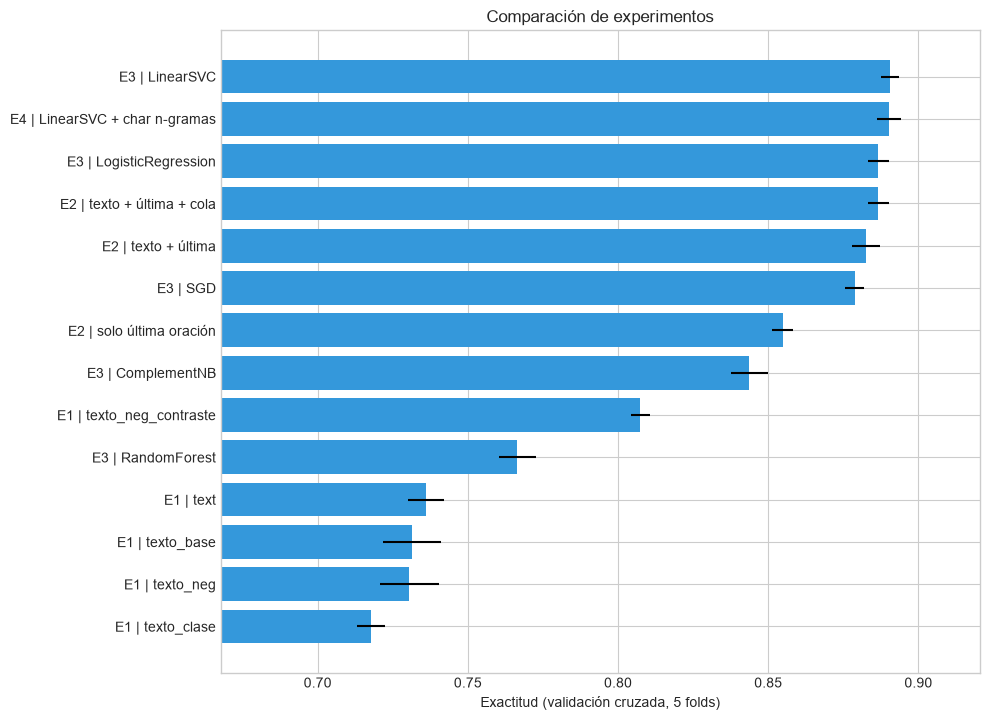

In [23]:
tabla_resultados = pd.DataFrame(resultados)
display(tabla_resultados.style.format({'acc_cv': '{:.4f}', 'std_cv': '{:.4f}', 'acc_train': '{:.4f}'})
        .background_gradient(subset=['acc_cv'], cmap='Greens'))

fig, ax = plt.subplots(figsize=(10, 0.45 * len(tabla_resultados) + 1))
orden = tabla_resultados.sort_values('acc_cv')
ax.barh(orden['experimento'], orden['acc_cv'], xerr=orden['std_cv'], color='#3498DB')
ax.set_xlim(orden['acc_cv'].min() - 0.05, min(1, orden['acc_cv'].max() + 0.03))
ax.set_xlabel('Exactitud (validación cruzada, 5 folds)')
ax.set_title('Comparación de experimentos')
plt.tight_layout()
plt.show()

### **8. Ajuste de hiperparámetros**

Sobre la mejor combinación (representación + clasificador) se hace una búsqueda en malla con la misma validación cruzada. Se ajustan la regularización del clasificador y el rango de n-gramas de palabras (el mismo para las tres columnas, para mantener la malla pequeña).

Búsqueda terminada en 25 s
Mejor exactitud CV: 0.8905
Mejores parámetros: {'clf__C': 0.5, 'tfidf__cola_prep__ngram_range': (1, 2), 'tfidf__texto_neg_contraste__ngram_range': (1, 2), 'tfidf__ultima_prep__ngram_range': (1, 2)}


,param_clf__C,ngram_range,mean_test_score,std_test_score,mean_train_score
7,0.5,"(1, 2)",0.8905,0.0030,0.9964
6,0.3,"(1, 2)",0.8894,0.0042,0.9898
8,1.0,"(1, 2)",0.8883,0.0029,0.9996
2,0.5,"(1, 1)",0.8882,0.0045,0.9648
1,0.3,"(1, 1)",0.8878,0.0054,0.9571
3,1.0,"(1, 1)",0.8869,0.0046,0.9741
12,0.5,"(1, 3)",0.8861,0.0041,0.9986
13,1.0,"(1, 3)",0.8854,0.0019,0.9999


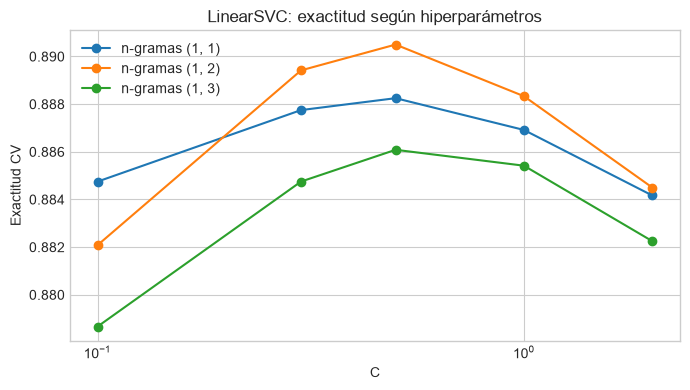

In [24]:
clf_base, grid_clf = CLASIFICADORES[MEJOR_CLF]
extra = [CHAR_ULTIMA] if USAR_CHAR else []
modelo_busqueda = modelo_columnas(COLUMNAS, clone(clf_base), extra=extra)

param_grid = [{**grid_clf, **{f'tfidf__{col}__ngram_range': [ng] for col in COLUMNAS}}
              for ng in [(1, 1), (1, 2), (1, 3)]]

inicio = time.time()
busqueda = GridSearchCV(modelo_busqueda, param_grid, cv=CV, scoring='accuracy', n_jobs=-1, return_train_score=True)
busqueda.fit(train, train['label'])
print(f'Búsqueda terminada en {time.time() - inicio:.0f} s')
print(f'Mejor exactitud CV: {busqueda.best_score_:.4f}')
print('Mejores parámetros:', busqueda.best_params_)

param_reg = list(grid_clf)[0]
col_ng = f'param_tfidf__{COLUMNAS[0]}__ngram_range'
cv_res = pd.DataFrame(busqueda.cv_results_)
cv_res['ngram_range'] = cv_res[col_ng].astype(str)
display(cv_res.sort_values('rank_test_score')[[f'param_{param_reg}', 'ngram_range', 'mean_test_score', 'std_test_score', 'mean_train_score']].head(8).round(4))

fig, ax = plt.subplots(figsize=(7, 4))
for ng, g in cv_res.groupby('ngram_range'):
    ax.plot(g[f'param_{param_reg}'].astype(float), g['mean_test_score'], marker='o', label=f'n-gramas {ng}')
ax.set_xscale('log'); ax.set_xlabel(param_reg.replace('clf__', '')); ax.set_ylabel('Exactitud CV')
ax.set_title(f'{MEJOR_CLF}: exactitud según hiperparámetros'); ax.legend()
plt.tight_layout(); plt.show()

resultados.append({'experimento': f'E5 | {MEJOR_CLF} ajustado', 'acc_cv': busqueda.best_score_,
                   'std_cv': cv_res.loc[busqueda.best_index_, 'std_test_score'],
                   'acc_train': cv_res.loc[busqueda.best_index_, 'mean_train_score'], 'segundos': round(time.time() - inicio, 1)})

**Resultados del ajuste:** la mejor configuración es C = 0.5 con uni y bigramas (0.8905), la misma con la que se partió.

- La superficie de exactitud es **plana** (todas las combinaciones están entre 0.885 y 0.891). El modelo es robusto a los hiperparámetros y el techo lo pone la representación, no el ajuste fino.
- Los trigramas sobreajustan (train ≈ 1.0 sin ganar en validación) y los unigramas pierden algo de contexto.
- Con C alto el modelo memoriza más (train → 1.0); con C bajo se regulariza demasiado.

### **9. Análisis de errores**

Se obtienen predicciones *out-of-fold* (cada reseña es predicha por un modelo que no la vio en entrenamiento) para analizar en qué se equivoca el mejor modelo.

              precision    recall  f1-score   support

    negativo     0.8585    0.8469    0.8526      4212
     neutral     0.9684    0.9947    0.9814      3576
    positivo     0.8538    0.8457    0.8497      4212

    accuracy                         0.8905     12000
   macro avg     0.8936    0.8957    0.8946     12000
weighted avg     0.8896    0.8905    0.8900     12000



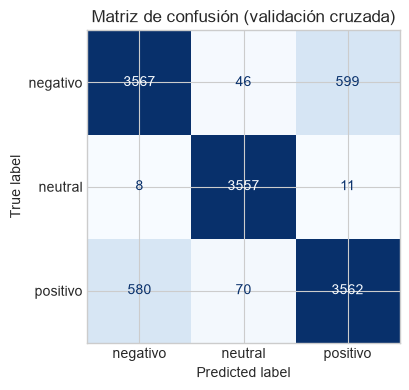

In [25]:
modelo_final = busqueda.best_estimator_
pred_cv = cross_val_predict(clone(modelo_final), train, train['label'], cv=CV, n_jobs=-1)

print(classification_report(train['label'], pred_cv, digits=4))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(train['label'], pred_cv, labels=CLASES, cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Matriz de confusión (validación cruzada)')
plt.tight_layout(); plt.show()

In [26]:
# Palabras con mayor peso por clase y por segmento (solo para modelos lineales)
clf_final = modelo_final.named_steps['clf']
if hasattr(clf_final, 'coef_'):
    nombres = modelo_final.named_steps['tfidf'].get_feature_names_out()
    pesos = pd.DataFrame(clf_final.coef_.T, index=nombres, columns=clf_final.classes_)
    top = {clase: pesos[clase].nlargest(12).index.tolist() for clase in CLASES}
    display(pd.DataFrame(top))

,negativo,neutral,positivo
0,ultima_prep__mal,texto_neg_contraste__vien,texto_neg_contraste__encim medi
1,ultima_prep__ruidos,texto_neg_contraste__color,ultima_prep__veloz
2,ultima_prep__decepcion,texto_neg_contraste__tra,ultima_prep__funcional
3,ultima_prep__poco fiabl,texto_neg_contraste__paquet,ultima_prep__decent
4,ultima_prep__pesim,texto_neg_contraste__kil,ultima_prep__sobresalient
5,ultima_prep__tras_mal,texto_neg_contraste__unidad,ultima_prep__espectacul
6,ultima_prep__pobr,texto_neg_contraste__volti,texto_neg_contraste__just busc
7,ultima_prep__torp,texto_neg_contraste__puert,ultima_prep__impec
8,ultima_prep__debil,ultima_prep__guard,ultima_prep__eficient
9,ultima_prep__defectu,texto_neg_contraste__pagin,ultima_prep__optim


In [27]:
errores = train.assign(pred=pred_cv).loc[lambda d: d['pred'] != d['label'], ['label', 'pred', 'text']]
print(f'Errores: {len(errores):,} de {len(train):,} ({len(errores) / len(train):.1%})')
with pd.option_context('display.max_colwidth', None):
    display(errores.sample(6, random_state=SEMILLA))

Errores: 1,314 de 12,000 (10.9%)


,label,pred,text
11279,negativo,positivo,"La compré en marzo por internet y me llegó en cuatro días a la oficina. Desde hace meses la llevo a todas partes, al trabajo, a los paseos de los domingos. Cada peso que pagué por la cámara valió la pena. Eso sí, estoy arrepentido de haber comprado esa relación calidad-precio, la verdad. No me queda claro con cuál quedarme, sopésalo tú mismo."
852,negativo,positivo,"Me llegó el sistema de sonido el jueves, lo pedí el lunes por internet. Estoy arrepentido de haberlo comprado. Por otro lado, le pondría cinco estrellas a la relación calidad-precio. Lo probé un rato en la sala y quedó conectado al televisor por el cable que traía de fábrica. Hay de todo, como se ve."
8855,positivo,negativo,"Lo compré a inicios de año y lo uso casi todos los días, la verdad le doy bastante uso. La duración de la carga me hizo la vida más fácil. Eso sí, la correa funciona bastante mal, lo he notado desde el primer mes y no ha mejorado. Queda a criterio de cada uno."
3891,positivo,negativo,"Desde hace meses, lo estoy probando a fondo. Le pondría cinco estrellas al soporte técnico. De paso, la atención al cliente funciona bastante mal. Sopésalo tú mismo."
10109,positivo,neutral,"Lo pedí en la tienda física de mi ciudad, tardó un par de días nada más en estar listo. Lo uso sobre todo los fines de semana para salir con la familia. Por cierto, la cámara me pareció buenísima desde el primer día. Aún no le saco todo el provecho pero por ahora va bien."
8071,positivo,neutral,"La compre hace un par de semanas y desde entonces la pruebo casi todos los dias, sobre todo en las tardes despues del trabajo. Viene en color rojo, que fue el que elegi al pedirla. La carcasa me parecio practica para mi gusto, se siente comoda al tomarla. Llego en tres dias a mi casa sin contratiempos."


**Análisis de errores:**

- **La clase neutral está prácticamente resuelta** (recall 0.995). Las reseñas neutrales no tienen palabras de opinión, y eso una bolsa de palabras lo detecta fácilmente.
- **Casi todos los errores son confusiones negativo ↔ positivo** en reseñas mixtas (un elogio y una queja). Allí el F1 baja a ~0.85.
- Las palabras con más peso para positivo y negativo vienen casi todas del segmento ultima_prep lo que confirma que el modelo aprendió a mirar el final de la reseña.
- Hay dos tipos de error:
  1. **Errores del modelo:** la última opinión no está en la última oración porque la reseña termina con una frase de cierre sin sentimiento ("Hay de todo, como se ve", "Sopésalo tú mismo", "Todavía no me decido"), o la opinión llega con un conector que no está en la lista ("Por cierto", "De paso", "Ahora,").
  2. **Casos que contradicen la regla de recencia:** reseñas cuya última opinión es negativa pero están etiquetadas como positivas (y viceversa), como las de índices 8855 y 3891. Pueden ser ruido de etiqueta o depender de algo que el texto no hace explícito. En cualquier caso, ponen un techo a lo que puede lograr una representación de bolsa de palabras.

### **10. Modelo final reproducible**

Para que el modelo entregado sea completamente replicable, se empaqueta **todo** el flujo en un único Pipeline que recibe el texto crudo: reparación de codificación, segmentación, preprocesamiento, vectorización y clasificación. Se entrena con todo train, se verifica que da exactamente las mismas predicciones que el modelo de la búsqueda y se guarda con joblib.



In [28]:
def construir_columnas(df, col_texto, kw_prep):
    """Del texto crudo genera las columnas que espera el modelo (misma lógica de las secciones 4 y 5)."""
    texto = df['text'].fillna('')
    ultima = texto.apply(ultima_oracion)
    return pd.DataFrame({
        col_texto: texto.apply(preprocesar, **kw_prep),
        'ultima_prep': ultima.apply(preprocesar, **kw_prep),
        'cola_prep': texto.apply(cola_contraste).apply(preprocesar, **kw_prep),
        'ultima': ultima,
    }, index=df.index)

pipeline_final = Pipeline([
    ('columnas', FunctionTransformer(construir_columnas, kw_args={'col_texto': MEJOR_VARIANTE, 'kw_prep': KW_PREP})),
    ('modelo', clone(modelo_final)),
])
pipeline_final.fit(train_raw[['text']], train_raw['label'])

pred_eval = pipeline_final.predict(eval_raw[['text']])
assert (pred_eval == modelo_final.predict(eval_df)).all(), 'El pipeline final no reproduce al modelo de la búsqueda'
print('✓ El pipeline sobre texto crudo reproduce exactamente las predicciones del modelo seleccionado')

Path('modelos').mkdir(exist_ok=True)
RUTA_MODELO = Path('modelos/modelo_final.joblib')
joblib.dump(pipeline_final, RUTA_MODELO)
cargado = joblib.load(RUTA_MODELO)
assert (cargado.predict(eval_raw[['text']]) == pred_eval).all()
print(f'✓ Modelo guardado y recargado correctamente: {RUTA_MODELO} ({RUTA_MODELO.stat().st_size / 1e6:.1f} MB)')

✓ El pipeline sobre texto crudo reproduce exactamente las predicciones del modelo seleccionado


✓ Modelo guardado y recargado correctamente: modelos\modelo_final.joblib (2.4 MB)


In [29]:
sample = pd.read_csv('data/sample_submission.csv')
Path('envios').mkdir(exist_ok=True)

def guardar_envio(nombre, predicciones):
    envio = pd.DataFrame({'id': eval_raw['id'], 'answer': predicciones})
    assert list(envio.columns) == list(sample.columns) and envio['id'].equals(sample['id'])
    assert envio['answer'].isin(CLASES).all()
    ruta = Path('envios') / f'{nombre}.csv'
    envio.to_csv(ruta, index=False)
    return ruta

ruta = guardar_envio('envio_05_modelo_final', pred_eval)
print(f'✓ Envío final: {ruta}')
display(pd.Series(pred_eval).value_counts(normalize=True).reindex(CLASES).round(3).to_frame('proporción predicha'))

✓ Envío final: envios\envio_05_modelo_final.csv


,proporción predicha
negativo,0.353
neutral,0.286
positivo,0.361


In [30]:
HITOS = {
    'envio_01_linea_base_clase':  ('Limpieza de clase + TF-IDF + LogReg', modelo_columnas(['texto_clase'])),
    'envio_02_preprocesar':       (f'{MEJOR_VARIANTE} + TF-IDF + LogReg', modelo_columnas([MEJOR_VARIANTE])),
    'envio_03_ultima_oracion':    ('+ TF-IDF de la última oración', modelo_columnas([MEJOR_VARIANTE, 'ultima_prep'])),
    'envio_04_cola_contraste':    ('+ TF-IDF de la cola contrastiva (LogReg)', modelo_columnas(COLUMNAS)),
}
acc_por_hito = {'envio_01_linea_base_clase': e1['texto_clase'], 'envio_02_preprocesar': e1[MEJOR_VARIANTE],
                'envio_03_ultima_oracion': e2['texto + última'], 'envio_04_cola_contraste': e2['texto + última + cola']}

registro = []
for nombre, (descripcion, modelo) in HITOS.items():
    guardar_envio(nombre, modelo.fit(train, train['label']).predict(eval_df))
    registro.append({'archivo': f'{nombre}.csv', 'descripcion': descripcion, 'acc_cv': acc_por_hito[nombre]})
registro.append({'archivo': 'envio_05_modelo_final.csv', 'descripcion': f"{MEJOR_CLF} ajustado ({param_reg.replace('clf__', '')} = {busqueda.best_params_[param_reg]})",
                 'acc_cv': busqueda.best_score_})

registro = pd.DataFrame(registro)
registro['kaggle_publico'] = np.nan   # completar con el puntaje público de cada envío
display(registro.round(4))

,archivo,descripcion,acc_cv,kaggle_publico
0,envio_01_linea_base_clase.csv,Limpieza de clase + TF-IDF + LogReg,0.7178,NaN
1,envio_02_preprocesar.csv,texto_neg_contraste + TF-IDF + LogReg,0.8074,NaN
2,envio_03_ultima_oracion.csv,+ TF-IDF de la última oración,0.8825,NaN
3,envio_04_cola_contraste.csv,+ TF-IDF de la cola contrastiva (LogReg),0.8867,NaN
4,envio_05_modelo_final.csv,LinearSVC ajustado (C = 0.5),0.8905,NaN


### **12. Conclusiones**

1. **El modelo final es un LinearSVC (C = 0.5) sobre tres TF-IDF de uni y bigramas**: texto completo con negación y marcas de contraste, última oración y cola desde el último conector contrastivo. Su exactitud en validación cruzada es **0.8905 ± 0.003**, frente a **0.718** de la línea base de clase.
2. **Lo que más aportó fue representar la posición, no cambiar de clasificador ni ajustar hiperparámetros.** El sentimiento global depende del orden de las cláusulas, y una bolsa de palabras sobre el texto completo lo ignora. Segmentar el texto (última oración, cola contrastiva) y marcar lo que va después de los conectores permitió inyectar parte de ese orden sin salir de las técnicas clásicas.
3. **Las decisiones de preprocesamiento deben adaptarse a la tarea.** Eliminar las *stopwords* genéricas borra *no*, *pero* y *muy*, que son claves para el sentimiento, y un *stemmer* en inglés no sirve para el español.
4. **Limitaciones:** la segmentación usa reglas fijas (lista de conectores, última oración) que fallan cuando la reseña termina con una frase de cierre neutral o usa un conector no contemplado. Una parte de los errores contradice incluso la regla de recencia.
5. **Siguiente paso (Parte 2):** un modelo secuencial (RNN, LSTM o *transformer*) puede aprender directamente cuál es la última cláusula con opinión, en lugar de depender de reglas, que es justo la limitación que deja este modelo.

**Reproducibilidad:** el archivo modelos/modelo_final.joblib contiene el pipeline completo (texto crudo → predicción) y corresponde al envío envios/envio_05_modelo_final.csv. Se entrena con semilla fija (SEMILLA = 42) y el notebook verifica que el modelo recargado reproduce exactamente las mismas predicciones.